In [1]:
import numpy as np
import torch
import matplotlib
from matplotlib import pyplot as plt
import scipy as sc

from generator import GeneratorBuilder
from potential import WolfeQuapp, WolfeQuappBiased
from aimmd import AIMMDNetwork, AIMMDCommittorTrainer
from wq_estimate_committor import wq_order_param_circle, q_A_B_from_R
from util import ress, correlate
from tps import load_umbrella_sampling_samples, generate_path_to_state_brownian

import json
from tqdm.auto import tqdm

import os

TO_CM = 1/2.54
matplotlib.rcParams.update({'font.size': 10})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

In [2]:
h = 4.0

q_A = q_A_B_from_R("A", 0.5, WolfeQuapp(h=h))
q_B = q_A_B_from_R("B", 0.5, WolfeQuapp(h=h))

param_dict= {"max": 2.3, "dx": 0.01, "ntrajectories" : 1000, "h": h, "qa": q_A, "qb": q_B, "target": "B", "timestep": 1e-2, "diffusioncoeff": 1.0, "orderparam": "circular"}

filename = "committor_estimates/wq"
for param_name, param in param_dict.items():
    filename += f"_{param_name}_{param}"
filename += ".csv"

loaded_committor_estimates = np.loadtxt(filename, delimiter=",")

side_length = int(np.sqrt(len(loaded_committor_estimates)))
sort_args = np.argsort(loaded_committor_estimates[:, 0]*side_length + loaded_committor_estimates[:, 1])

committor_estimates = loaded_committor_estimates[sort_args]

X = committor_estimates[:, 0].reshape(side_length, side_length).T[0].flatten()
Y = committor_estimates[:, 1].reshape(side_length, side_length).T[:, 0].flatten()

committor_values = committor_estimates[:, 2].reshape(side_length, side_length)
committor_values = sc.ndimage.gaussian_filter(committor_values, 5)

interp = sc.interpolate.RegularGridInterpolator((X, Y), committor_values, bounds_error=False)

def cv_function(coords):
    coords = np.where(np.abs(coords) < 2.3, coords, np.sign(coords)*2.299)
    return interp(coords)

unwrapped_potential = WolfeQuappBiased(h=h, k_bias=300, cv_function=cv_function)
cv_gradient_function = unwrapped_potential.cv_gradient

class CVFunctionAutograd(torch.autograd.Function):

    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)

        coords = input.detach().cpu().numpy()
        cv_values = cv_function(coords)

        return torch.from_numpy(cv_values).to(input.device)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        coords = input.detach().cpu().numpy()
        grad = torch.from_numpy(cv_gradient_function(coords)).to(input.device)

        return grad*grad_output[..., None]
    
def cv_function_wrapper(coords):
    return CVFunctionAutograd.apply(coords)

potential = WolfeQuappBiased(h=h, k_bias=300, cv_function=cv_function_wrapper)

# Sample SPs and generate paths

  0%|          | 0/30 [00:00<?, ?it/s]

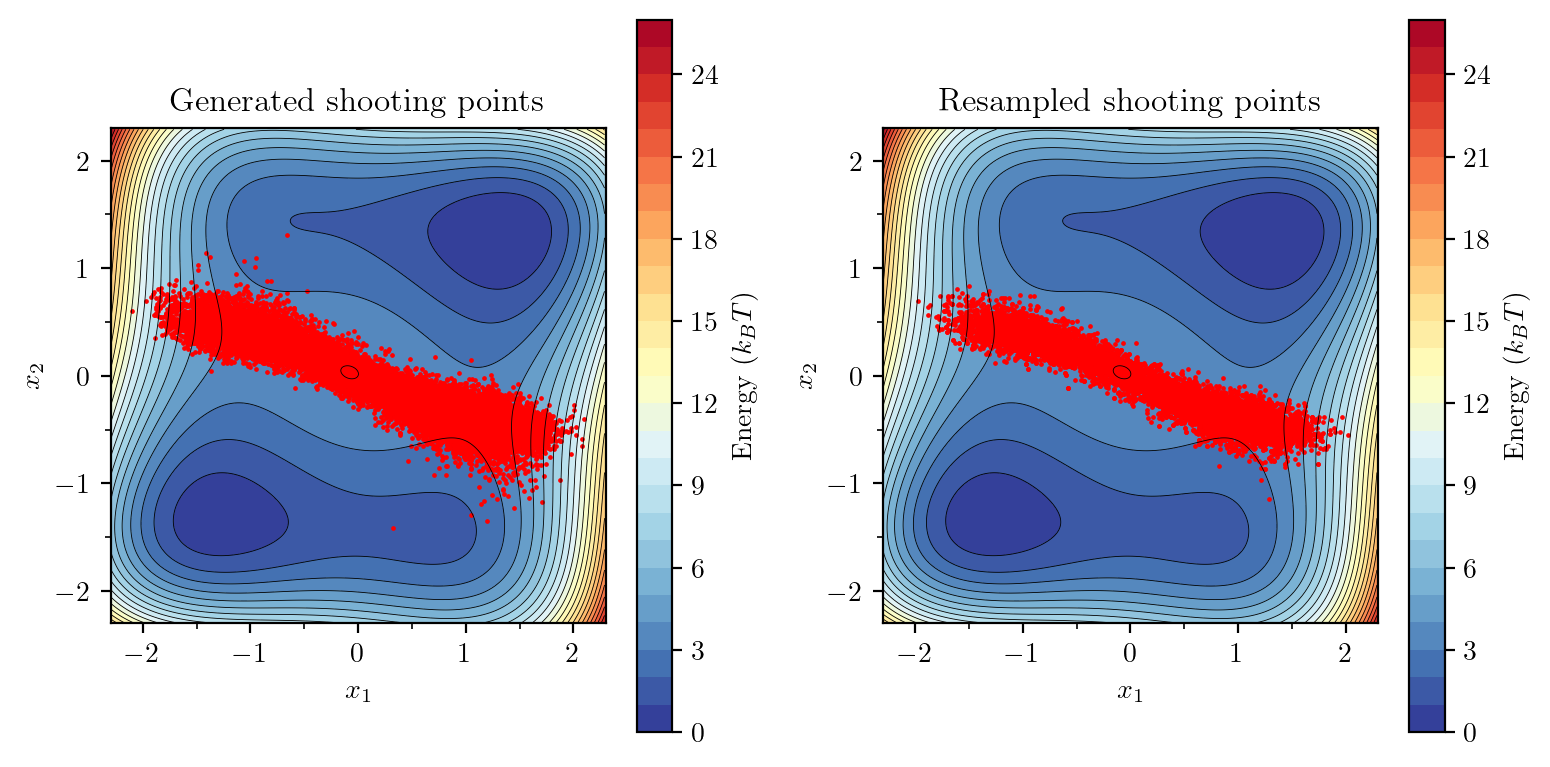

In [ ]:
generator = torch.load(f"generators/wq_conditioned_h_{h}_orderparam_circular.pt", weights_only=False).to("cpu")
generator.reference_beta = 1.0
generator.transform_layers = []

n_samples = 25000

N_REPEATS = 30

for repeat in tqdm(range(1, N_REPEATS + 1)):
    generator_input = torch.hstack([generator.generate_z_samples(n_samples), (torch.ones(n_samples)*0.5).reshape(-1, 1)]).to(generator.device)
    generated_sps, log_R_zx = generator.F_zx(generator_input)

    sp_weights = generator.get_weights(generated_sps, log_R_zx, generator_input, normalize=True).detach().numpy()
    indices_chosen = np.random.choice(len(generated_sps), 10_000, p=sp_weights)

    generated_sps = generated_sps[:, :-1].detach().numpy()
    resampled_sps = generated_sps[indices_chosen]

    np.savetxt(f"wq_tps_generated/resampled_sps_{repeat}.csv", resampled_sps, delimiter=',')

    if repeat == 1:
        fig, ax = plt.subplots(1, 2, figsize=(20*TO_CM, 10*TO_CM), dpi=200)

        unwrapped_potential.plot_PES(fig, ax[0], title="Generated shooting points", fill=True)
        unwrapped_potential.plot_PES(fig, ax[1], title="Resampled shooting points", fill=True)

        ax[0].scatter(generated_sps[:, 0], generated_sps[:, 1], s=0.5, color="red")
        ax[1].scatter(resampled_sps[:, 0], resampled_sps[:, 1], s=0.5, color="red")

        ax[0].set_xlim((-2.3, 2.3))
        ax[0].set_ylim((-2.3, 2.3))

        ax[1].set_ylim((-2.3, 2.3))
        ax[1].set_xlim((-2.3, 2.3))

        fig.tight_layout()

        plt.show()

In [5]:
print("Run wq_tps_comparison_generated_paths.py to generate the transition paths from these shooting points in parallel and save them.")

Run wq_tps_comparison_generated_paths.py to generate the transition paths from these shooting points in parallel and save them.


# Abs. error of $p(x | TP)$

In [4]:
bins = 40
bin_edges = np.linspace(-2.3, 2.3, bins + 1)
bin_centers = (bin_edges[1:] + bin_edges[:-1])/2

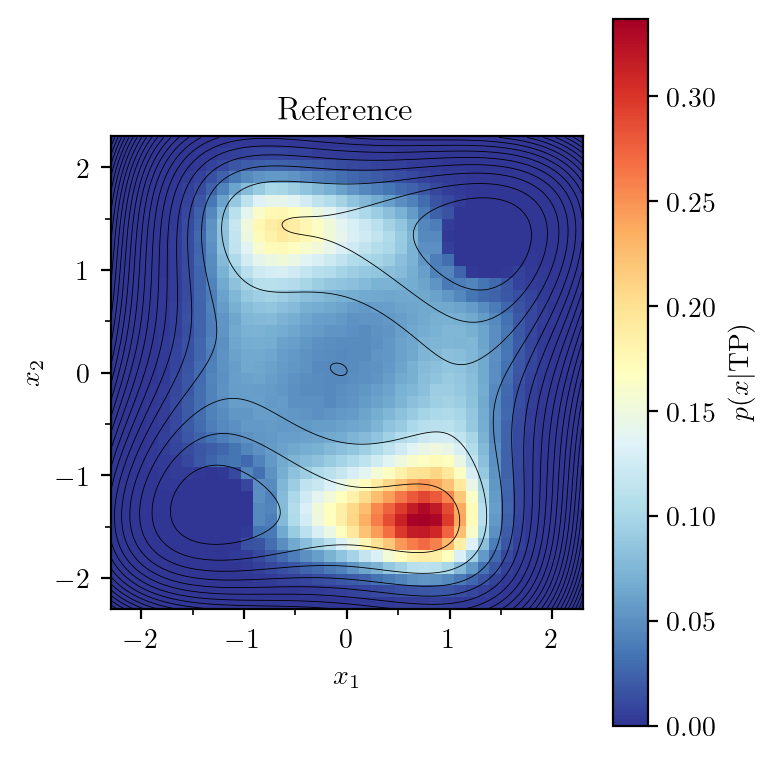

In [5]:
reference_paths = []
with open("samples/wq_tps_nsamples_25000_nout_500_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.001_diffusioncoeff_1.0_orderparam_circular.json", "r") as file:
    for line in file.read().splitlines():
        reference_paths.append(np.array(json.loads(line)))

x_data = np.array([item for path in reference_paths for item in path[:, 0]]).flatten()
y_data = np.array([item for path in reference_paths for item in path[:, 1]]).flatten()

reference_path_lengths = np.array(list(map(len, reference_paths)))

reference_p_x_TP = np.histogram2d(x_data, y_data, bins=bin_edges, density=True)[0]

fig, ax = plt.subplots(1, 1, figsize=(10*TO_CM, 10*TO_CM), dpi=200)

potential.plot_PES(fig, ax, title="Reference", fill=False)

image = ax.imshow(reference_p_x_TP.T, cmap="RdYlBu_r", vmin=0, origin="lower", extent=(bin_edges[0], bin_edges[-1], bin_edges[0], bin_edges[-1]), aspect="auto")
cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$p(x | \mathrm{TP})$")

ax.set_xlim((-2.3, 2.3))
ax.set_ylim((-2.3, 2.3))

ax.set_aspect('equal')

fig.tight_layout()

plt.show()


In [ ]:
n_files = 30

all_errors = []

for i in tqdm(range(1, n_files + 1)):
    with open(f"wq_tps_normal/{i}.json", "r") as file:
        errors = []

        normal_paths = []
        counter = 1
        for line in file.read().splitlines():
            normal_paths += json.loads(line)

            if counter % 10 == 0:
                x_data = np.array(normal_paths)[:, 0]
                y_data = np.array(normal_paths)[:, 1]

                normal_p_x_TP = np.histogram2d(x_data, y_data, bins=bin_edges, density=True)[0].flatten()

                errors.append(np.abs(normal_p_x_TP - reference_p_x_TP.flatten()).sum())
                
            counter += 1
            
        all_errors.append(errors)

np.savetxt("wq_tps_normal/errors.csv", np.array(all_errors), delimiter=",")

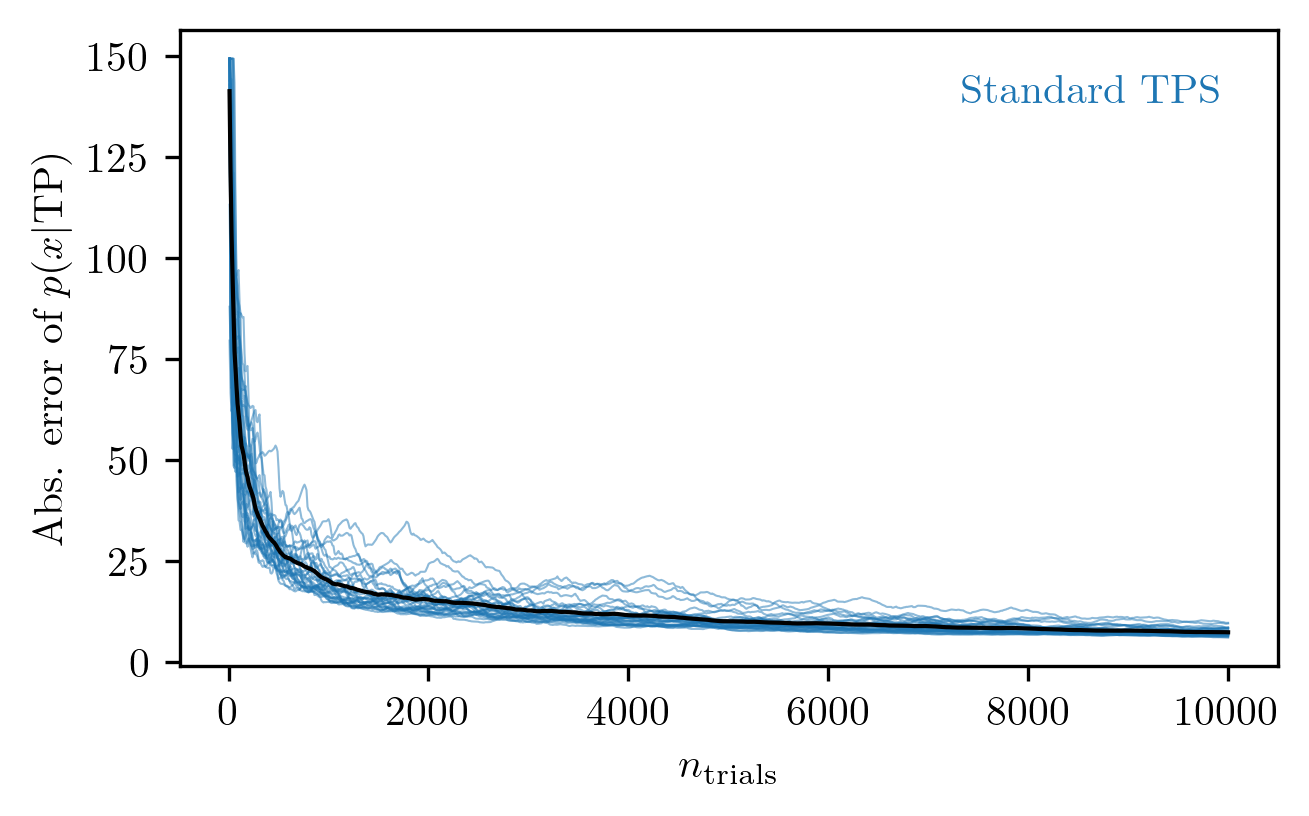

In [7]:
all_errors = np.loadtxt("wq_tps_normal/errors.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(10, 10_000 + 10, 10)

for error in all_errors:
    ax.plot(x, error, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_errors = np.mean(all_errors, axis=0)
ax.plot(x, mean_errors, color="black", linewidth=1)

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"Abs. error of $p(x | \mathrm{TP})$")

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

plt.show()

In [ ]:
n_files = 30

all_errors = []

pbar = tqdm(total=n_files*10_000)

for i in range(1, n_files + 1):
    with open(f"wq_tps_generated/{i}.json", "r") as file:
        errors = []

        generated_paths = []
        path_weights = []
        all_path_weights = np.loadtxt(f"wq_tps_generated/path_weights_{i}.csv", delimiter=",")

        counter = 1
        for path_idx, line in enumerate(file.read().splitlines()):
            new_path = json.loads(line)
            path_weight = all_path_weights[path_idx]

            generated_paths += new_path
            path_weights += [path_weight]*len(new_path)

            if counter % 10 == 0:
                x_data = np.array(generated_paths)[:, 0]
                y_data = np.array(generated_paths)[:, 1]
                weights = np.array(path_weights)

                generated_p_x_TP = np.histogram2d(x_data, y_data, bins=bin_edges, density=True, weights=weights)[0].flatten()

                errors.append(np.abs(generated_p_x_TP - reference_p_x_TP.flatten()).sum())

            counter += 1
            pbar.update()

        all_errors.append(errors)

np.savetxt("wq_tps_generated/errors.csv", np.array(all_errors), delimiter=",")

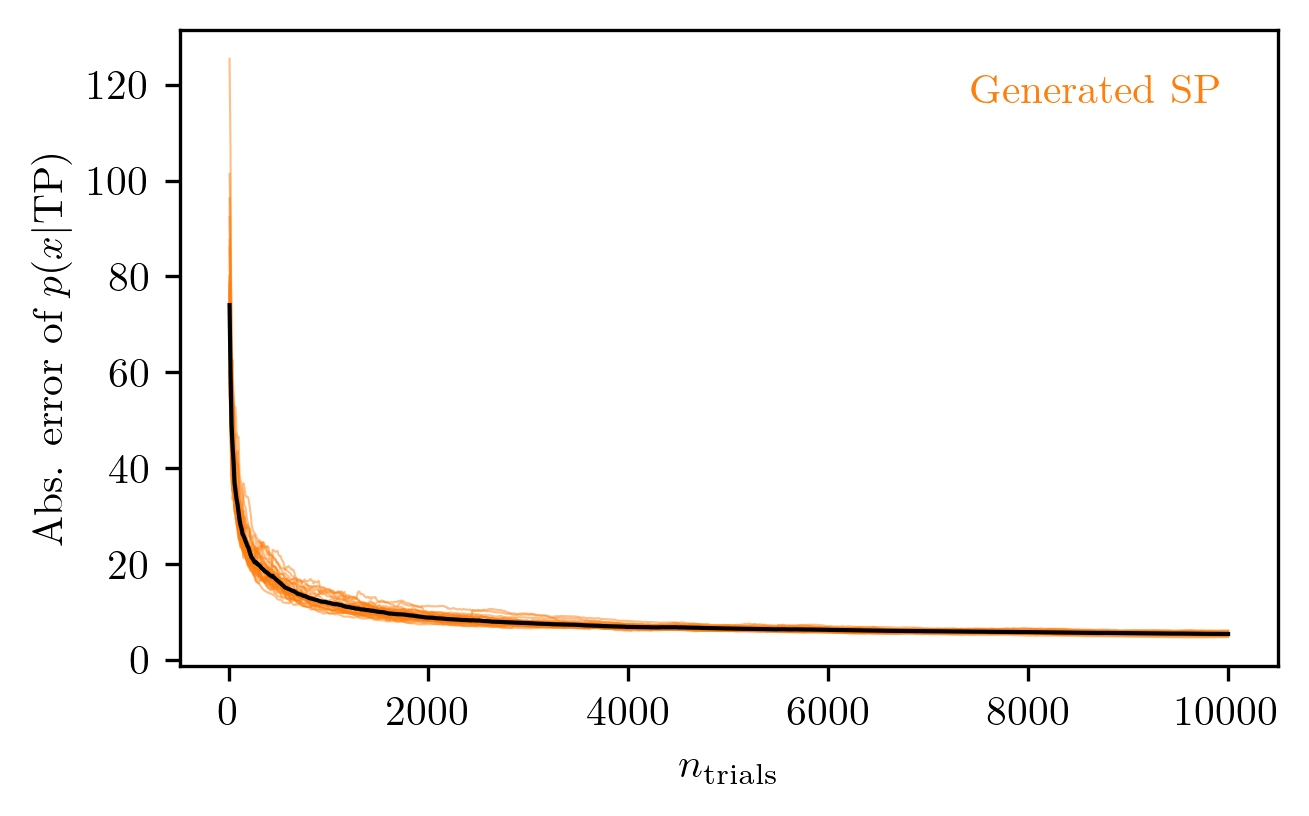

In [8]:
all_errors = np.loadtxt("wq_tps_generated/errors.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(10, 10_000 + 10, 10)

for error in all_errors:
    ax.plot(x, error, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_errors = np.mean(all_errors, axis=0)
ax.plot(x, mean_errors, color="black", linewidth=1)

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"Abs. error of $p(x | \mathrm{TP})$")

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

plt.show()

# Indicator function $\bar{g}(n)$

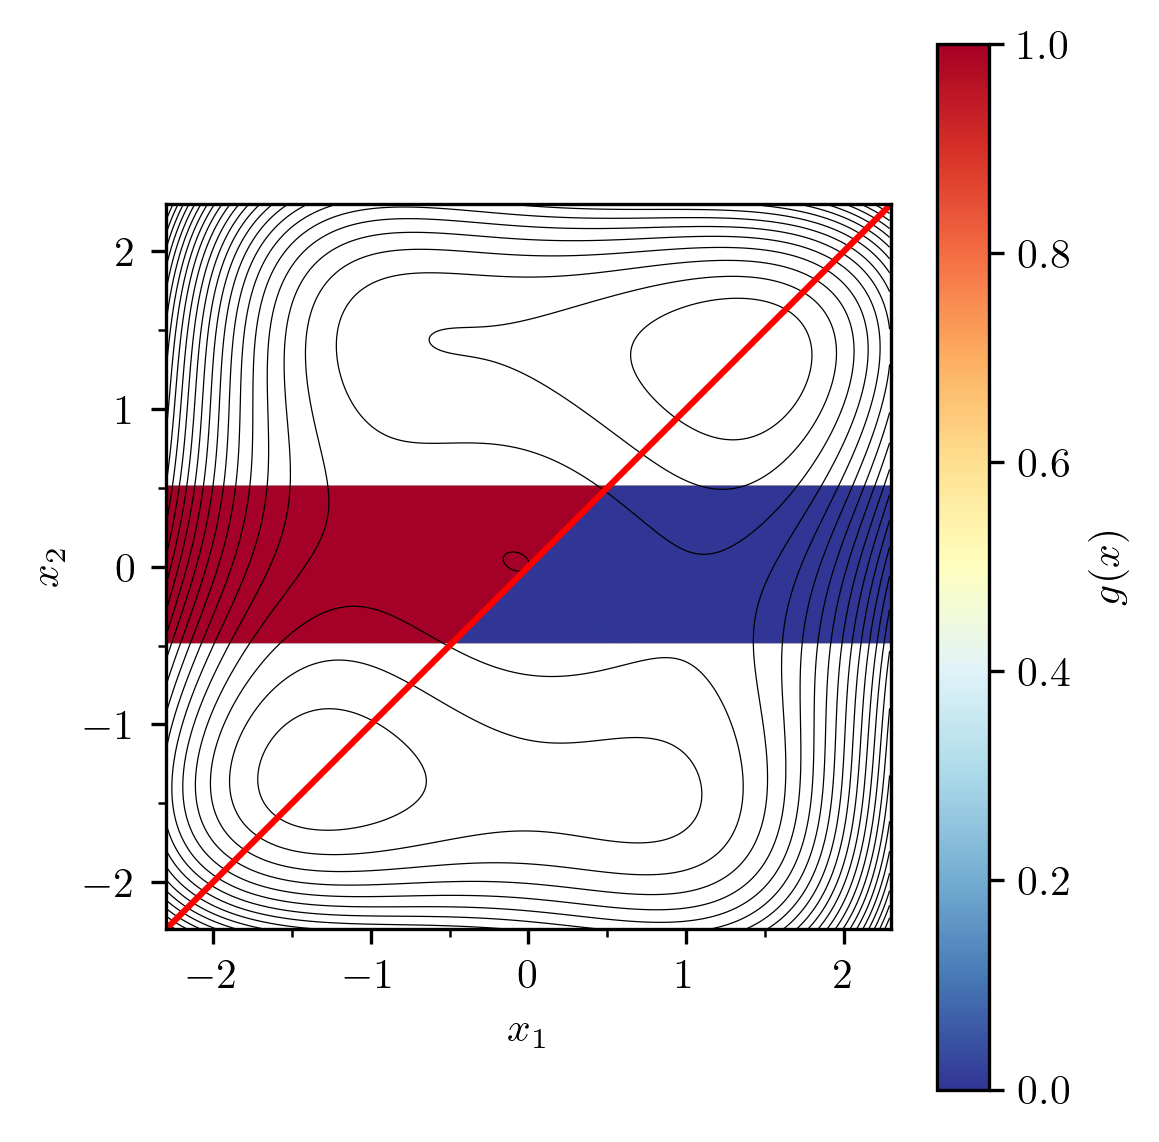

In [9]:
def g(path):
    mask = np.abs(path[..., 1]) < 0.5
    path = path[mask]

    if len(path) == 0:
        return np.nan

    projection = path[..., 1] - path[..., 0]

    return np.round((np.sign(np.mean(projection)) + 1) / 2)

X, Y = np.meshgrid(np.arange(-2.3, 2.3, 0.01), np.arange(-2.3, 2.3, 0.01))
grid = np.array([[X[i, j], Y[i, j]] for i in range(X.shape[0]) for j in range(X.shape[1])])
g_values = np.array([g(grid_point) for grid_point in grid]).reshape(X.shape)

fig, ax = plt.subplots(1, 1, figsize=(10*TO_CM, 10*TO_CM), dpi=300)

unwrapped_potential.plot_PES(fig, ax, fill=False)

image = ax.imshow(g_values, cmap="RdYlBu_r", vmin=0, vmax=1, origin="lower", extent=(-2.3, 2.3, -2.3, 2.3), aspect="auto")

ax.plot([-2.3, 2.3], [-2.3, 2.3], color="red")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$g(x)$")

ax.set_xlim((-2.3, 2.3))
ax.set_ylim((-2.3, 2.3))

ax.set_aspect('equal')

fig.tight_layout()

plt.show()

In [ ]:
n_files = 30

all_gs = []

for i in tqdm(range(1, n_files + 1)):
    with open(f"wq_tps_normal/{i}.json", "r") as file:
        gs = []

        for line in file.read().splitlines():
            path = np.array(json.loads(line))

            gs.append(g(path))
            
        all_gs.append(gs)

np.savetxt("wq_tps_normal/gs.csv", np.array(all_gs), delimiter=",")

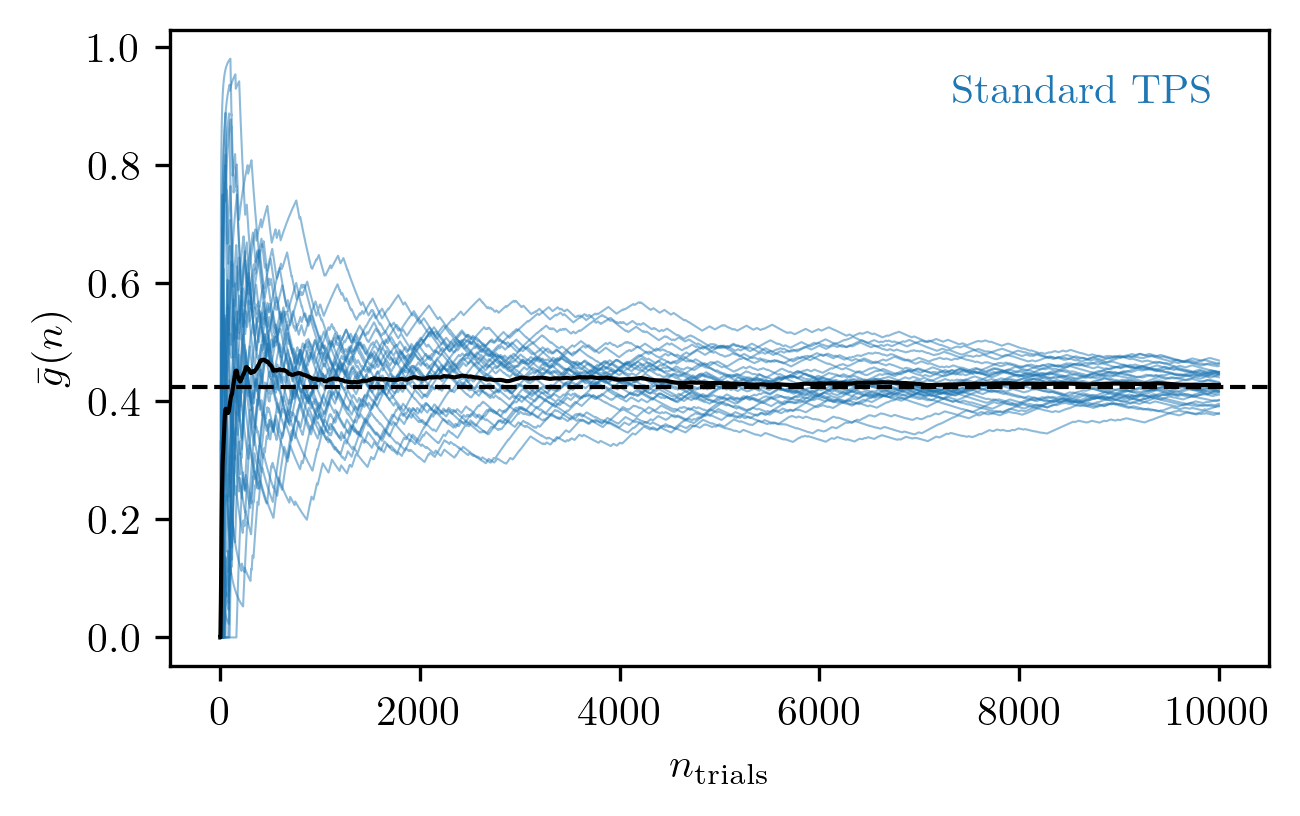

In [10]:
all_gs = np.loadtxt("wq_tps_normal/gs.csv", delimiter=",")

running_mean_gs = np.cumsum(all_gs, axis=-1)/np.arange(1, all_gs.shape[-1]+1)

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(1, 10_000 + 1, 1)

for running_mean_g in running_mean_gs:
    ax.plot(x, running_mean_g, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_mean_gs = np.mean(running_mean_gs, axis=0)
ax.plot(x, mean_mean_gs, color="black", linewidth=1)

reference_gs = []
with open("samples/wq_tps_nsamples_25000_nout_500_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.001_diffusioncoeff_1.0_orderparam_circular.json") as file:
    for line in file.read().splitlines():
        reference_gs.append(g(np.array(json.loads(line))))

ax.axhline(y=np.nanmean(reference_gs), linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"$\bar{g}(n)$")

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

plt.show()

In [ ]:
n_files = 30

all_gs = []

for i in tqdm(range(1, n_files + 1)):
    all_paths = []
    path_weights = np.loadtxt(f"wq_tps_generated/path_weights_{i}.csv")

    with open(f"wq_tps_generated/{i}.json", "r") as file:
        for line in file.read().splitlines():
            all_paths.append(np.array(json.loads(line)))

        chosen_indices = np.random.choice(len(all_paths), len(all_paths), replace=True, p=path_weights/np.sum(path_weights))

        gs = [g(all_paths[i]) for i in chosen_indices]
        all_gs.append(gs)

np.savetxt("wq_tps_generated/gs.csv", np.array(all_gs), delimiter=",")

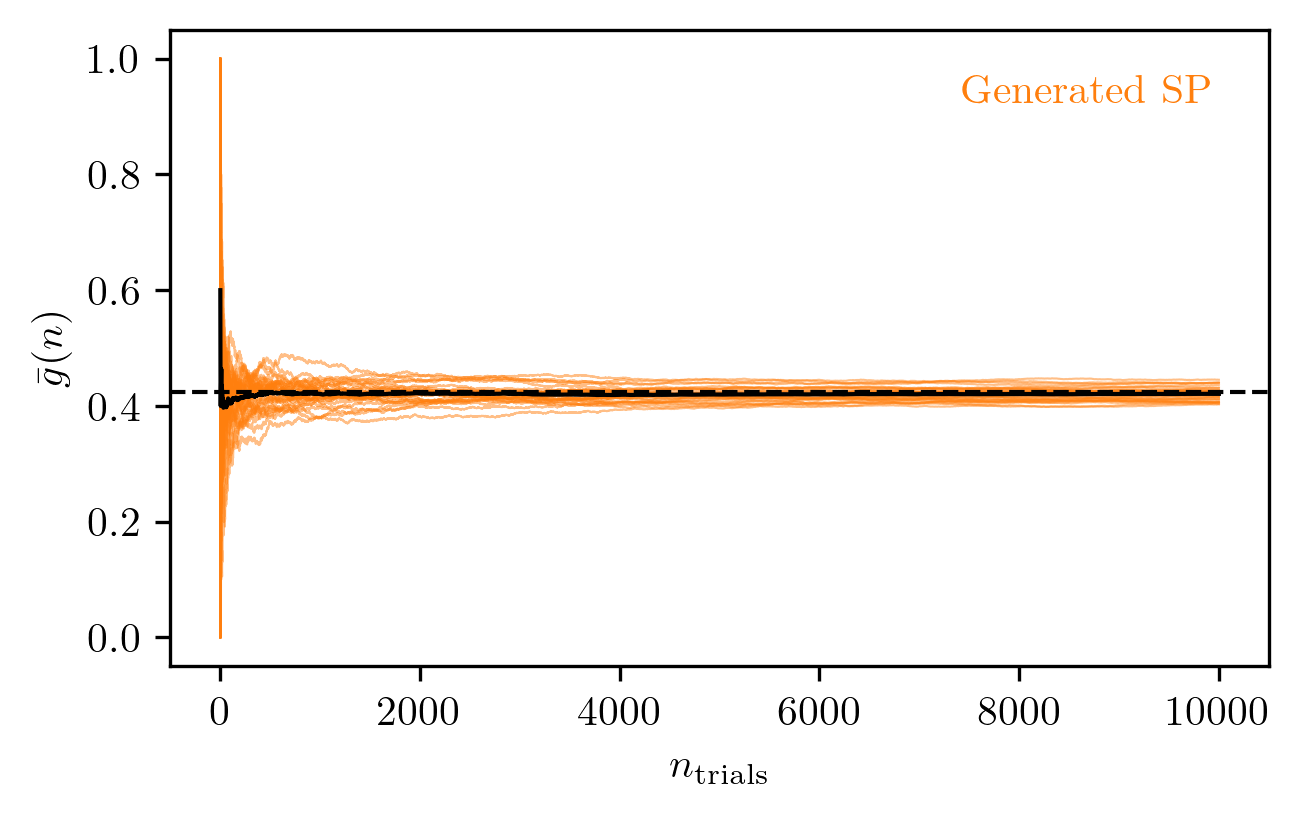

In [11]:
all_gs = np.loadtxt("wq_tps_generated/gs.csv", delimiter=",")

running_mean_gs = np.cumsum(all_gs, axis=-1)/np.arange(1, all_gs.shape[-1]+1)

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

x = np.arange(1, 10_000 + 1, 1)

for running_mean_g in running_mean_gs:
    ax.plot(x, running_mean_g, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_mean_gs = np.mean(running_mean_gs, axis=0)
ax.plot(x, mean_mean_gs, color="black", linewidth=1)

reference_gs = []
with open("samples/wq_tps_nsamples_25000_nout_500_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.001_diffusioncoeff_1.0_orderparam_circular.json") as file:
    for line in file.read().splitlines():
        reference_gs.append(g(np.array(json.loads(line))))

ax.axhline(y=np.nanmean(reference_gs), linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$n_{\mathrm{trials}}$")
ax.set_ylabel(r"$\bar{g}(n)$")

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

plt.show()

# Correlation function $C_{g(X)}(k)$

In [ ]:
n_files = 30

all_gs = np.loadtxt("wq_tps_normal/gs.csv", delimiter=",")

correlation_functions = [correlate(gs, gs) for gs in all_gs]

np.savetxt("wq_tps_normal/correlation_function_gs.csv", np.array(correlation_functions), delimiter=",")

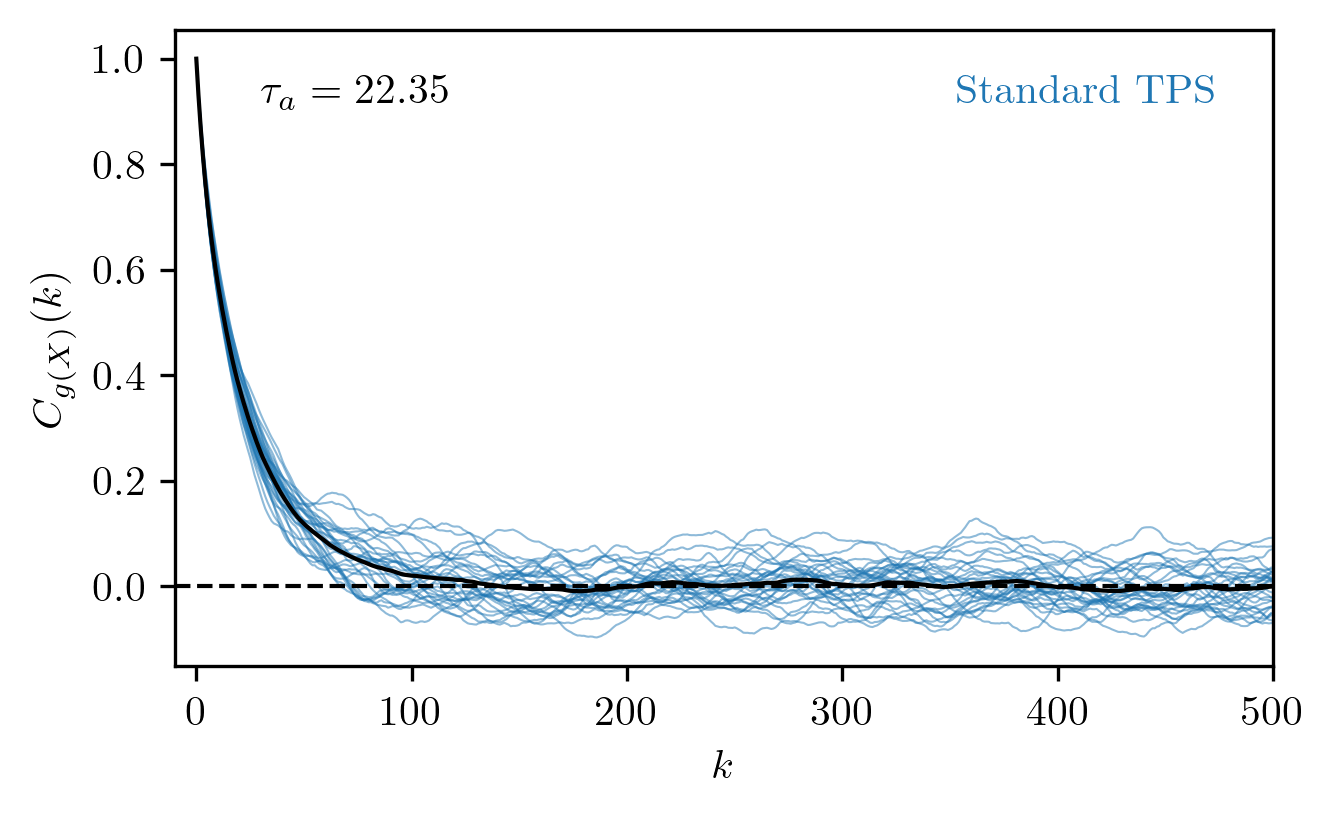

In [12]:
M = 500

correlation_functions = np.loadtxt("wq_tps_normal/correlation_function_gs.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

for correlation_function in correlation_functions:
    ax.plot(correlation_function[:M], color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=0.5, linewidth=0.5)

mean_correlation_function = np.mean(correlation_functions, axis=0)

autocorrelation_time = 0.5 + np.sum(mean_correlation_function[1:M+1])

ax.plot(mean_correlation_function[:M], color="black", linewidth=1)

ax.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$C_{g(X)}(k)$")

ax.set_xlim((-10, M))

ax.text(0.95, 0.9, f"Standard TPS", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][0])

ax.text(0.25, 0.9, r"$\tau_a = " + str(round(autocorrelation_time, 2)) + "$", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes,)

plt.show()

In [ ]:
n_files = 30

all_gs = np.loadtxt("wq_tps_generated/gs.csv", delimiter=",")

correlation_functions = [correlate(gs, gs) for gs in all_gs]

np.savetxt("wq_tps_generated/correlation_function_gs.csv", np.array(correlation_functions), delimiter=",")

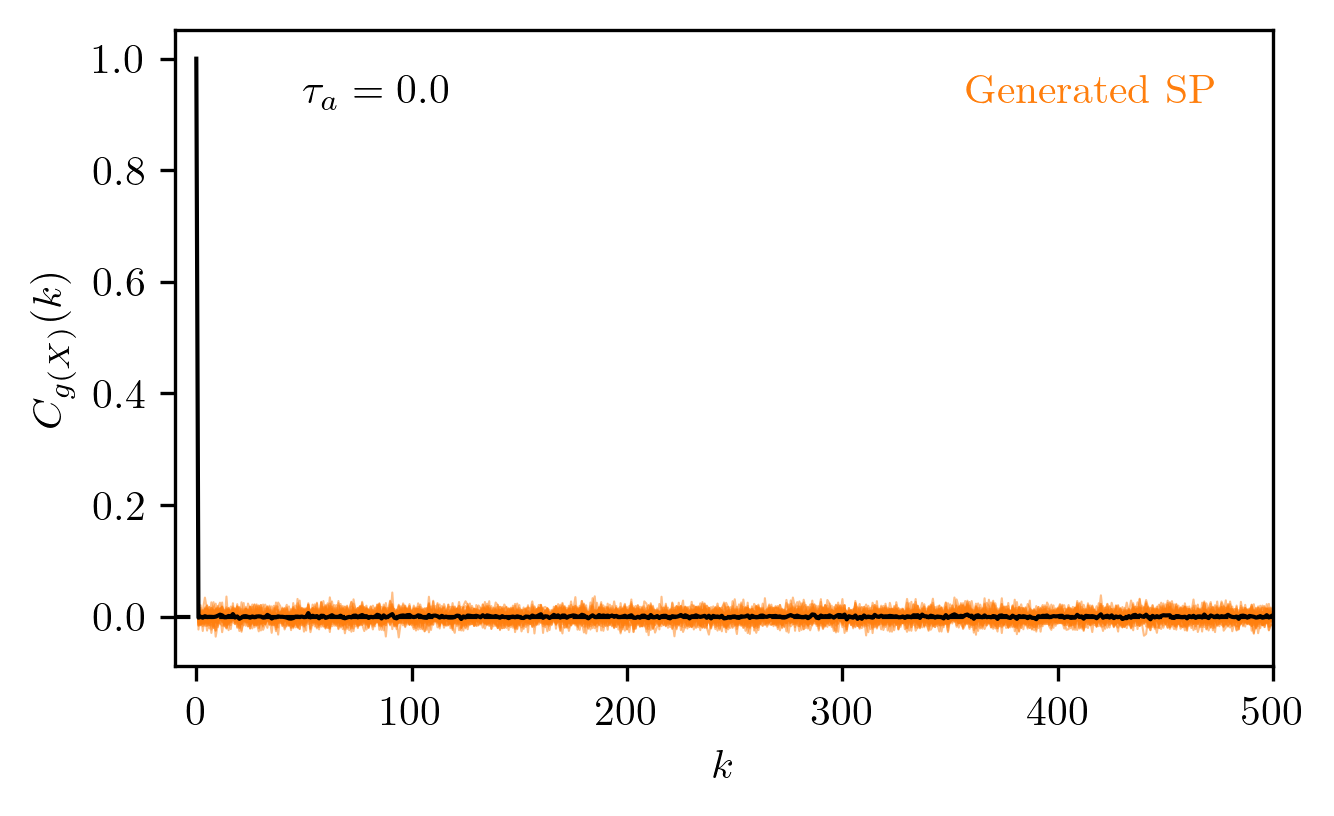

In [13]:
M = 500

correlation_functions = np.loadtxt("wq_tps_generated/correlation_function_gs.csv", delimiter=",")

fig, ax = plt.subplots(1, 1, figsize=(12*TO_CM, 7*TO_CM), dpi=300)

for correlation_function in correlation_functions:
    ax.plot(correlation_function[:M], color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=0.5, linewidth=0.5)

mean_correlation_function = np.mean(correlation_functions, axis=0)

autocorrelation_time = 0.0

ax.plot(mean_correlation_function[:M], color="black", linewidth=1)

ax.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$C_{g(X)}(k)$")

ax.set_xlim((-10, M))

ax.text(0.95, 0.9, f"Generated SP", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes, color=matplotlib.rcParams['axes.prop_cycle'].by_key()['color'][1])

ax.text(0.25, 0.9, r"$\tau_a = " + str(round(autocorrelation_time, 2)) + "$", horizontalalignment='right', verticalalignment='center', transform=ax.transAxes,)

plt.show()

# Combined plot

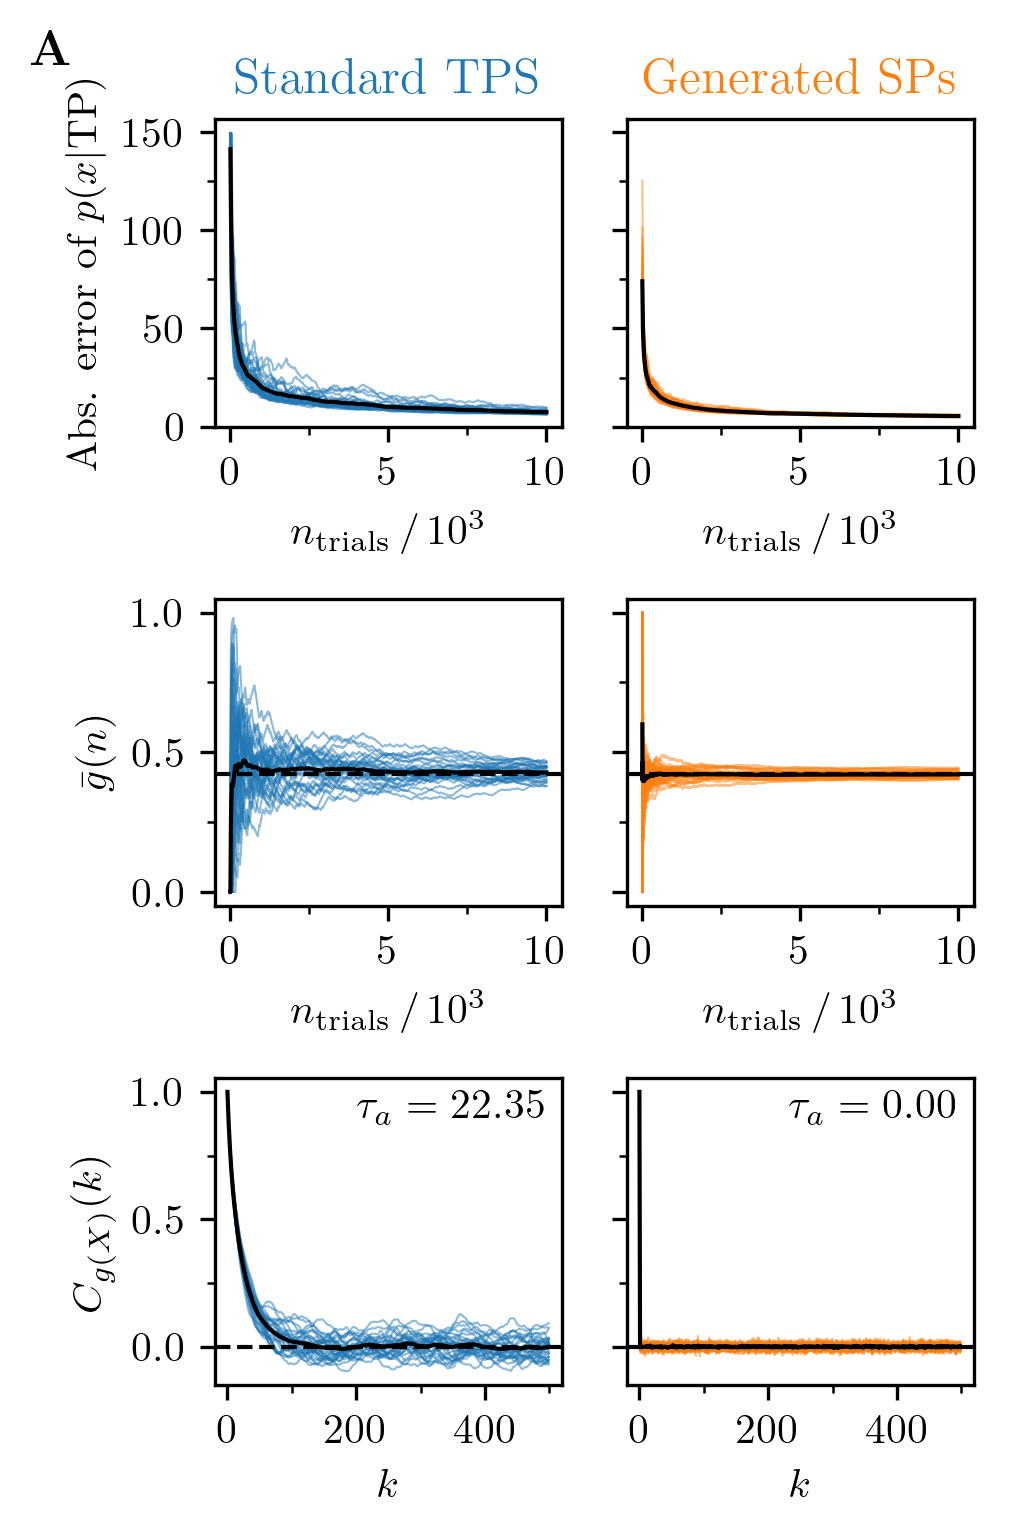

In [14]:
from matplotlib import ticker

M = 500

colors = matplotlib.rcParams['axes.prop_cycle'].by_key()['color']
columns = [("wq_tps_normal", "Standard TPS", colors[0]),
           ("wq_tps_generated", "Generated SPs", colors[1])]


reference_gs = []
with open("samples/wq_tps_nsamples_25000_nout_500_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.001_diffusioncoeff_1.0_orderparam_circular.json") as file:
    for line in file.read().splitlines():
        reference_gs.append(g(np.array(json.loads(line))))

reference_g = np.nanmean(reference_gs)
fig, axes = plt.subplots(3, len(columns), figsize=(8.5*TO_CM, 13*TO_CM), dpi=300, sharey='row')

for column, (folder, label, color) in enumerate(columns):
    ax_error, ax_g, ax_correlation = axes[:, column]

    ax_error.set_title(label, color=color)

    all_errors = np.loadtxt(f"{folder}/errors.csv", delimiter=",")

    x = np.arange(10, 10_000 + 10, 10)

    for error in all_errors:
        ax_error.plot(x, error, color=color, alpha=0.5, linewidth=0.5)

    mean_errors = np.mean(all_errors, axis=0)
    ax_error.plot(x, mean_errors, color="black", linewidth=1)

    ax_error.set_xlabel(r"$n_{\mathrm{trials}}$")

    all_gs = np.loadtxt(f"{folder}/gs.csv", delimiter=",")

    running_mean_gs = np.cumsum(all_gs, axis=-1)/np.arange(1, all_gs.shape[-1]+1)

    x = np.arange(1, 10_000 + 1, 1)

    for running_mean_g in running_mean_gs:
        ax_g.plot(x, running_mean_g, color=color, alpha=0.5, linewidth=0.5)

    mean_mean_gs = np.mean(running_mean_gs, axis=0)
    ax_g.plot(x, mean_mean_gs, color="black", linewidth=1)

    ax_g.axhline(y=reference_g, linewidth=1.0, ls='dashed', color="black")

    ax_g.set_xlabel(r"$n_{\mathrm{trials}}$")

    correlation_functions = np.loadtxt(f"{folder}/correlation_function_gs.csv", delimiter=",")

    for correlation_function in correlation_functions:
        ax_correlation.plot(correlation_function[:M], color=color, alpha=0.5, linewidth=0.5)

    mean_correlation_function = np.mean(correlation_functions, axis=0)

    if folder == "wq_tps_generated":
        autocorrelation_time = 0.0
    else:
        autocorrelation_time = 0.5 + np.sum(mean_correlation_function[1:M+1])

    ax_correlation.plot(mean_correlation_function[:M], color="black", linewidth=1)

    ax_correlation.axhline(y=0.0, linewidth=1.0, ls='dashed', color="black")

    ax_correlation.set_xlabel(r"$k$")
    ax_correlation.set_xlim((-20, M+20))

    ax_correlation.text(0.95, 0.9, r"$\tau_a = " + f"{autocorrelation_time:.2f}" + "$", horizontalalignment='right', verticalalignment='center', transform=ax_correlation.transAxes)

axes[0, 0].set_ylabel(r"Abs. error of $p(x | \mathrm{TP})$")
axes[1, 0].set_ylabel(r"$\bar{g}(n)$")
axes[2, 0].set_ylabel(r"$C_{g(X)}(k)$")

axes[0, 0].set_ylim((0, axes[0, 0].get_ylim()[1]))

for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10]))

    for axis in (ax.xaxis, ax.yaxis):
        axis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.tick_params(which='minor', length=2)

for ax in axes[:2].flat:
    if max(abs(limit) for limit in ax.get_xlim()) >= 10_000:
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda value, _: f"{value/1000:g}"))
        ax.set_xlabel(ax.get_xlabel() + r"$\,/\,10^{3}$")

fig.tight_layout()

fig.text(0.01, 0.99, r"\textbf{A}", horizontalalignment='left', verticalalignment='top', fontsize=12)

plt.show()